In [1]:
dataset = '1313_SYN_70'

In [2]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score, roc_curve, auc, f1_score
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import LabelEncoder
from ultralytics import YOLO
from sklearn.model_selection import train_test_split
import cv2
import seaborn as sns

In [3]:
train_dir = str('DS_REAL_SPLITED_' + dataset)

model = YOLO("yolo12n-cls.yaml")

model.train(data=train_dir, epochs=300, imgsz=64, project='YOLO12-RESULTS', name=dataset)

YOLO12n-cls summary: 152 layers, 1,820,976 parameters, 1,820,976 gradients, 3.7 GFLOPs
New https://pypi.org/project/ultralytics/8.3.230 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.169 🚀 Python-3.11.0rc1 torch-2.0.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=DS_REAL_SPLITED_1313_SYN_70, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=300, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=64, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n-cls.

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/conv.py:459: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv2d(input, weight, bias, self.stride,


AMP: checks passed ✅
train: Fast image access ✅ (ping: 2.1±0.3 ms, read: 9.7±1.5 MB/s, size: 35.3 KB)


train: Scanning /tf/2025/SEEDS/DS_REAL_SPLITED_1313_SYN_70/train... 5940 images, 0 corrupt: 100%|██████████| 5940/5940 [


train: New cache created: /tf/2025/SEEDS/DS_REAL_SPLITED_1313_SYN_70/train.cache
val: Fast image access ✅ (ping: 2.6±0.2 ms, read: 8.6±1.2 MB/s, size: 41.8 KB)


...

                   all      0.775      0.993



300 epochs completed in 1.780 hours.
Optimizer stripped from YOLO12-RESULTS/1313_SYN_70/weights/last.pt, 3.7MB
Optimizer stripped from YOLO12-RESULTS/1313_SYN_70/weights/best.pt, 3.7MB

Validating YOLO12-RESULTS/1313_SYN_70/weights/best.pt...
Ultralytics 8.3.169 🚀 Python-3.11.0rc1 torch-2.0.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
YOLO12n-cls summary (fused): 94 layers, 1,722,450 parameters, 0 gradients, 3.5 GFLOPs
train: /tf/2025/SEEDS/DS_REAL_SPLITED_1313_SYN_70/train... found 5940 images in 10 classes ✅ 
val: /tf/2025/SEEDS/DS_REAL_SPLITED_1313_SYN_70/val... found 750 images in 10 classes ✅ 
test: /tf/2025/SEEDS/DS_REAL_SPLITED_1313_SYN_70/test... found 750 images in 10 classes ✅ 


               classes   top1_acc   top5_acc: 100%|██████████| 24/24 [00:00<00:00, 25.56it/s]


                   all      0.777      0.995
Speed: 0.1ms preprocess, 0.3ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to YOLO12-RESULTS/1313_SYN_70


ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fefd6d3c3d0>
curves: []
curves_results: []
fitness: 0.886000007390976
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.7773333191871643, 'metrics/accuracy_top5': 0.9946666955947876, 'fitness': 0.886000007390976}
save_dir: PosixPath('YOLO12-RESULTS/1313_SYN_70')
speed: {'preprocess': 0.0723228839924559, 'inference': 0.33030210536283755, 'loss': 0.0001339186953070263, 'postprocess': 0.00032041064696386456}
task: 'classify'
top1: 0.7773333191871643
top5: 0.9946666955947876

In [4]:
from pathlib import Path
from PIL import Image
from sklearn.metrics import classification_report

def avaliar_modelo(model, val_path, imgsz=64, verbose=False):

    val_path = Path(val_path)

    class_names = sorted([d.name for d in val_path.iterdir() if d.is_dir()])
    class_to_idx = {cls_name: idx for idx, cls_name in enumerate(class_names)}

    y_true = []
    y_pred = []

    for cls_name in class_names:
        cls_dir = val_path / cls_name
        label = class_to_idx[cls_name]

        for img_path in cls_dir.glob("*.*"):  # jpg, png, etc.
            try:
                img = Image.open(img_path).convert("RGB")
                results = model.predict(img, imgsz=imgsz, verbose=False)
                pred = int(results[0].probs.top1)

                y_true.append(label)
                y_pred.append(pred)

                if verbose:
                    print(f"Imagem: {img_path.name} | Real: {cls_name} | Previsto: {class_names[pred]}")

            except Exception as e:
                print(f"[ERRO] Falha ao processar {img_path.name}: {e}")

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    acc = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=class_names)

    print(f"\n🔍 Acurácia: {acc:.4f}")
    print(report)

    return y_true, y_pred, report

In [5]:
# Carregue seu modelo (pré-treinado ou treinado)
model = YOLO(str('YOLO12-RESULTS/' + dataset + '/weights/best.pt'))

# Caminho para pasta de validação
val_path = str('DS_REAL_SPLITED_' + dataset + '/test')

# Avaliação
y_true, y_pred, relatorio = avaliar_modelo(model, val_path, imgsz=64, verbose=False)



🔍 Acurácia: 0.7547
                   precision    recall  f1-score   support

      BULKCARRIER       0.72      0.55      0.62        75
    CONTAINERSHIP       0.84      0.84      0.84        75
     GENERALCARGO       0.57      0.63      0.60        75
OILPRODUCTSTANKER       0.55      0.31      0.39        75
   PASSENGERSSHIP       0.80      0.85      0.83        75
           TANKER       0.52      0.80      0.63        75
          TRAWLER       0.83      0.73      0.78        75
              TUG       0.92      0.92      0.92        75
  VEHICLESCARRIER       0.90      0.96      0.93        75
            YACHT       0.94      0.96      0.95        75

         accuracy                           0.75       750
        macro avg       0.76      0.75      0.75       750
     weighted avg       0.76      0.75      0.75       750



In [6]:
def plotar_metricas(y_true, y_pred):
    """
    Gera os gráficos de Acurácia, Precisão, Recall e a Matriz de Confusão.
    """
    # 1. Acurácia
    accuracy = accuracy_score(y_true, y_pred)

    # 2. Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    # 3. Precision
    precision = precision_score(y_true, y_pred, average='macro')

    # 4. Recall
    recall = recall_score(y_true, y_pred, average='macro')

    #5. F1-Score
    f1 = f1_score(y_true, y_pred, average='macro')

    # Plot 1: Gráfico de Acurácia, Precisão e Recall
    metrics = [accuracy, precision, recall, f1]
    metrics_names = ['Acurácia', 'Precisão', 'Recall', 'f1_score']

    plt.figure(figsize=(8, 6))
    plt.bar(metrics_names, metrics, color=['blue', 'green', 'orange', 'yellow'])
    plt.title('Acurácia, Precisão, Recall & F1')
    plt.ylim(0, 1)
    plt.ylabel('Valor')
    for i, value in enumerate(metrics):
        plt.text(i, value + 0.02, f'{value:.4f}', ha='center', va='bottom', fontsize=12)
    plt.show()

    # Plot 2: Matriz de Confusão
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=np.arange(1, cm.shape[1] + 1), yticklabels=np.arange(1, cm.shape[0] + 1))
    plt.title('Matriz de Confusão')
    plt.xlabel('Predições')
    plt.ylabel('Verdadeiros')
    plt.show()

    print(f'Acurácia: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1 Score: {f1:.4f}')
    print(f'Confusion Matrix:\n{cm}')

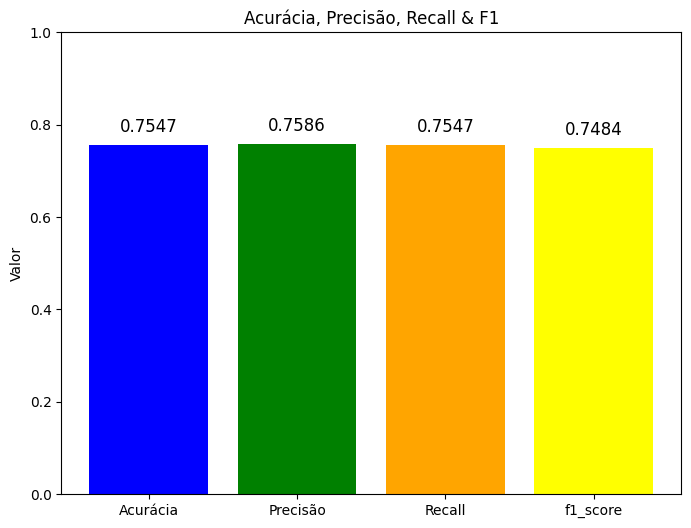

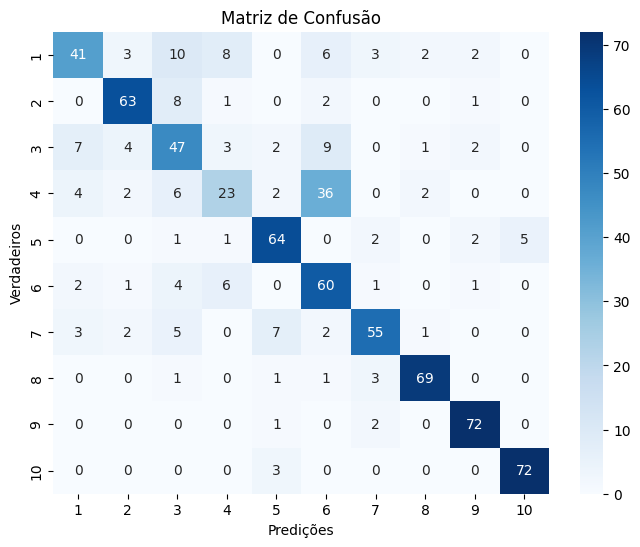

Acurácia: 0.7547
Precision: 0.7586
Recall: 0.7547
F1 Score: 0.7484
Confusion Matrix:
[[41  3 10  8  0  6  3  2  2  0]
 [ 0 63  8  1  0  2  0  0  1  0]
 [ 7  4 47  3  2  9  0  1  2  0]
 [ 4  2  6 23  2 36  0  2  0  0]
 [ 0  0  1  1 64  0  2  0  2  5]
 [ 2  1  4  6  0 60  1  0  1  0]
 [ 3  2  5  0  7  2 55  1  0  0]
 [ 0  0  1  0  1  1  3 69  0  0]
 [ 0  0  0  0  1  0  2  0 72  0]
 [ 0  0  0  0  3  0  0  0  0 72]]


In [7]:
%matplotlib inline
plotar_metricas(y_true, y_pred)